In [8]:
# Install necessary packages
!pip install emoji scikit-learn transformers sentencepiece torch

In [9]:
from huggingface_hub import login
import os
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [10]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch

In [11]:
file_path = "fixed_balanced_emotion_dataset.csv"
df = pd.read_csv(file_path, encoding='latin1')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Dataset shape: (10330, 4)
Columns: ['Unnamed: 0', 'Tweets', 'Level 1', 'Level 2']


,Unnamed: 0,Tweets,Level 1,Level 2
0,7706,Han ji sir wait thoda sa bhari ho gya apka,no emotion,Neutral
1,11561,please make a vedio of gwader sea khe hander e...,no emotion,Neutral
2,4377,very nice apki videos bahot achi hoti han,emotion,Happy


In [12]:
df_clean = df.copy()

In [13]:
# Basic Cleaning
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s:]", " ", text)  # keep emoji codes
    text = re.sub(r"\s+"," ",text).strip()
    return text.lower()

In [14]:
# Urdu Normalization
norm_rules = {
    # 1. Phrases
    r"\b(bahut acha|bohot acha|bht acha)\b": "very good",
    r"\b(bohot ganda|bahut ganda|bht ganda)\b": "very bad",
    r"\b(bilkul nahi|bilkul nhi)\b": "not at all",
    r"\b(nahi kiya|nhi kiya)\b": "did not",
    r"\b(nahi hai|nhi hai|hai nahi)\b": "is not",
    r"\b(mat karo|mat kar)\b": "do not",
    r"\b(nahi tha|nhi tha)\b": "was not",
    r"\b(bura laga|bura lga)\b": "felt bad",

    # 2. Negations
    r"\b(nai|nhi|nahi|naa|ney|na|no)\b": "not",

    # 3. Intensifiers
    r"\b(bohot|bohat|bht|bhut|bahut)\b": "very",

    # 4. Positive Variations
    r"\b(achaa|achha|acha|achia)\b": "good",
    r"\b(khubsurat|khoobsurat|khubsorat)\b": "beautiful",
    r"\b(zabbardast|zabardast|zabrthast)\b": "amazing",
    r"\b(kamaal|kamal)\b": "amazing",
    r"\b(lajawaab|lajawab)\b": "excellent",
    r"\b(shandaar|shandar)\b": "wonderful",
    r"\b(pasand|psand)\b": "liked",
    r"\b(khushi|khush)\b": "happy",
    r"\b(mast|m मस्त)\b": "great",
    r"\b(wahh|waah|wah)\b": "wow",
    r"\b(badhiya|bdhiya)\b": "great",

    # 5. Negative Variations
    r"\b(bekar|bekaar|baykar)\b": "useless",
    r"\b(ghatya|ghatia)\b": "worst",
    r"\b(kharab|kharib|kharaab)\b": "bad",
    r"\b(bura|burra)\b": "bad",
    r"\b(ganda|gndaa)\b": "bad",
    r"\b(bewaqoof|bewakoof|bewaqof)\b": "stupid",
    r"\b(ghaleez|ghaleez)\b": "disgusting",
    r"\b(napassand|napasand)\b": "disliked",
    r"\bnagawar\b": "unpleasant",
    r"\btaklif\b": "pain",
    r"\b(dukh|dukk)\b": "sadness",
    r"\b(dard|drd)\b": "pain",
    r"\b(gussa|ghussa)\b": "angry",
    r"\b(pareshaan|preshan)\b": "troubled",
    r"\bafsos\b": "regret",
    r"\bnalayak\b": "incompetent",

    # 6. Social/Slang
    r"\b(ya|yar|yaar)\b": "yaar",
    r"\b(plz|pls|please)\b": "please",
    r"\b(thx|thanks|thnx)\b": "thanks",
    r"\bhahaha+\b": "haha",
    r"\b(haii|hay|haye)\b": "bhai",
}

def normalize_roman(text):
    for pattern,repl in norm_rules.items():
        text = re.sub(pattern,repl,text)
    return text

In [15]:
# Reduce repetitions
def remove_repeats(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

In [16]:
# Map emotion to sentiment
emotion_to_sentiment = {
    "Anger":0,
    "Sad":0,
    "Fear":0,
    "Disgust":0,
    "Happy":2,
    "Surprise":2,
    "Neutral":1
}

In [17]:
df_clean["clean_text"] = df_clean["Tweets"].apply(clean_text)

df_clean["clean_text"] = df_clean["clean_text"].apply(lambda x: emoji.demojize(x))

df_clean["normalized_text"] = df_clean["clean_text"].apply(normalize_roman)

df_clean["normalized_text"] = df_clean["normalized_text"].apply(remove_repeats)

df_clean["label_id"] = df_clean["Level 2"].map(emotion_to_sentiment)
df_clean = df_clean.dropna(subset=["label_id"])

In [18]:
# Back translation onf 5% of dataset using MarianMT
from transformers import MarianMTModel, MarianTokenizer

# English → Urdu
en2ur_model_name = "Helsinki-NLP/opus-mt-en-ur"
en2ur_tokenizer = MarianTokenizer.from_pretrained(en2ur_model_name)
en2ur_model = MarianMTModel.from_pretrained(en2ur_model_name)

# Urdu → English
ur2en_model_name = "Helsinki-NLP/opus-mt-ur-en"
ur2en_tokenizer = MarianTokenizer.from_pretrained(ur2en_model_name)
ur2en_model = MarianMTModel.from_pretrained(ur2en_model_name)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/848k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [19]:
def back_translate(texts, batch_size=16):
    augmented_texts = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # 1. Urdu -> English
        tokens = ur2en_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids = ur2en_model.to("cuda").generate(**tokens)
        en_texts = [ur2en_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids]

        # 2. English -> Urdu
        tokens2 = en2ur_tokenizer(en_texts, return_tensors="pt", padding=True, truncation=True).to("cuda")
        translated_ids2 = en2ur_model.to("cuda").generate(**tokens2)
        ur_texts = [en2ur_tokenizer.decode(g, skip_special_tokens=True) for g in translated_ids2]

        augmented_texts.extend(ur_texts)
        print(f"Processed {len(augmented_texts)}/{len(texts)}...")

    return augmented_texts

In [20]:
df_aug = df_clean.sample(frac=0.05, random_state=42).copy()
df_aug["normalized_text"] = back_translate(df_aug["normalized_text"].tolist())

Processed 16/516...
Processed 32/516...
Processed 48/516...
Processed 64/516...
Processed 80/516...
Processed 96/516...
Processed 112/516...
Processed 128/516...
Processed 144/516...
Processed 160/516...
Processed 176/516...
Processed 192/516...
Processed 208/516...
Processed 224/516...
Processed 240/516...
Processed 256/516...
Processed 272/516...
Processed 288/516...
Processed 304/516...
Processed 320/516...
Processed 336/516...
Processed 352/516...
Processed 368/516...
Processed 384/516...
Processed 400/516...
Processed 416/516...
Processed 432/516...
Processed 448/516...
Processed 464/516...
Processed 480/516...
Processed 496/516...
Processed 512/516...
Processed 516/516...


In [21]:
# Combine original and augmented
df_final = pd.concat([df_clean, df_aug], ignore_index=True)
print("After augmentation:", len(df_final))

After augmentation: 10846


In [22]:
from transformers import MBartForSequenceClassification, MBart50TokenizerFast

tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")
#tokenizer.src_lang = "en_XX"
tokenizer.src_lang = "hi_IN"

tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

In [23]:
df_final = df_final[["normalized_text", "label_id"]].copy()
df_final = df_final.dropna(subset=["normalized_text", "label_id"])
df_final = df_final[df_final["normalized_text"].str.strip().astype(bool)]
df_final = df_final[df_final["label_id"].isin([0, 1, 2])]
df_final["label_id"] = df_final["label_id"].astype(int)

In [24]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from collections import Counter

train, test = train_test_split(df_final, test_size=0.15, random_state=42, stratify=df_final["label_id"])
train, val  = train_test_split(train,    test_size=0.15, random_state=42, stratify=train["label_id"])

target = len(train[train["label_id"] == 1])
train_balanced = pd.concat([
    resample(train[train["label_id"] == 0], replace=True, n_samples=target, random_state=42),
    train[train["label_id"] == 1],
    resample(train[train["label_id"] == 2], replace=True, n_samples=target, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train balanced:", Counter(train_balanced["label_id"]))
print("Val  (original):", Counter(val["label_id"]))
print("Test (original):", Counter(test["label_id"]))

Train balanced: Counter({2: 2267, 0: 2267, 1: 2267})
Val  (original): Counter({0: 537, 2: 446, 1: 400})
Test (original): Counter({0: 631, 2: 525, 1: 471})


In [25]:
train_balanced.to_csv("train_processed.csv", index=False)
val.to_csv("val_processed.csv", index=False)
test.to_csv("test_processed.csv", index=False)

print("Full preprocessing + tokenization complete")

Full preprocessing + tokenization complete


PEFT Fine Tuning

In [43]:
from datasets import Dataset

def prepare_dataset(df):
    hf_ds = Dataset.from_pandas(
        df[["normalized_text", "label_id"]].reset_index(drop=True)
    )

    def tokenize_fn(batch):
        return tokenizer(
            batch["normalized_text"],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors=None
        )

    hf_ds = hf_ds.map(tokenize_fn, batched=True)
    hf_ds = hf_ds.rename_column("label_id", "labels")
    hf_ds.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )
    return hf_ds

In [44]:
train_ds = prepare_dataset(train_balanced)
val_ds   = prepare_dataset(val)
test_ds  = prepare_dataset(test)

print("Sample input_ids shape:", train_ds[0]["input_ids"].shape)
print("Sample attention_mask shape:", train_ds[0]["attention_mask"].shape)
print("Sample label:", train_ds[0]["labels"])

Map:   0%|          | 0/6801 [00:00<?, ? examples/s]

Map:   0%|          | 0/1383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1627 [00:00<?, ? examples/s]

Sample input_ids shape: torch.Size([128])
Sample attention_mask shape: torch.Size([128])
Sample label: tensor(2)


In [45]:
from collections import Counter
import torch

label_counts = Counter(train_balanced["label_id"])
print("Label distribution:", label_counts)

total = sum(label_counts.values())
class_weights = torch.tensor(
    [total / (3 * label_counts[i]) for i in range(3)],
    dtype=torch.float
).to("cuda")
print("Class weights:", class_weights)

Label distribution: Counter({2: 2267, 0: 2267, 1: 2267})
Class weights: tensor([1., 1., 1.], device='cuda:0')


In [67]:
from transformers import MBartForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

peft_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)
peft_model.config.pad_token_id = tokenizer.pad_token_id
peft_model.get_input_embeddings().weight.requires_grad = True

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
MBartForSequenceClassification LOAD REPORT from: facebook/mbart-large-50
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
lm_head.weight                      | UNEXPECTED | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 
classif

In [68]:
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 17,334,368 || all params: 1,141,377,123 || trainable%: 1.5187


In [69]:
from transformers import TrainingArguments, Trainer

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [78]:
training_args = TrainingArguments(
    output_dir="./mbart-peft-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    logging_steps=50,
    lr_scheduler_type="linear",
    warmup_steps=500,
    gradient_accumulation_steps=4,
    max_grad_norm=1.0,
    label_smoothing_factor=0.1,
    report_to="none"
)

In [79]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  if isinstance(logits, tuple):
    logits = logits[0]

  preds = np.argmax(logits, axis=-1)

  return {
      "accuracy": accuracy_score(labels, preds),
      "f1": f1_score(labels, preds, average="weighted")
  }


In [80]:
from accelerate.state import AcceleratorState, PartialState
from transformers import default_data_collator
AcceleratorState._reset_state(reset_partial_state=True)
PartialState()


trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=peft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [81]:
import time

start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.882481,0.786793,0.656544,0.657197
2,2.802993,0.794725,0.653651,0.658356
3,2.646761,0.802857,0.647867,0.648607
4,2.472946,0.814824,0.643529,0.646446
5,2.397446,0.790255,0.658713,0.660499
6,2.310109,0.813693,0.651482,0.655354


Total Training Time: 1431.73 seconds


In [82]:
def peft_predict_sentiment(text, neutral_threshold=0.65):
  peft_model.eval()
  device = next(peft_model.parameters()).device

  text = clean_text(text)
  text = emoji.demojize(text)
  text = normalize_roman(text)
  text = remove_repeats(text)

  inputs = tokenizer(
      text, return_tensors="pt",
      padding=True, truncation=True, max_length=128
  ).to(device)

  with torch.no_grad():
      logits = peft_model(**inputs).logits

  probs = torch.softmax(logits, dim=-1)[0]


  if probs[1] >= neutral_threshold:
      pred = 1
  else:
      neg_pos_probs = probs.clone()
      neg_pos_probs[1] = 0
      pred = torch.argmax(neg_pos_probs).item()

  label_map = {
      0: "Negative (Anger/Sad/Fear/Disgust)",
      1: "Neutral",
      2: "Positive (Happy/Surprise)"
  }
  print(f"Prediction : {label_map[pred]}")
  print(f"Confidence → Neg: {probs[0]:.3f} | Neu: {probs[1]:.3f} | Pos: {probs[2]:.3f}")
  return label_map[pred]


Prediction : Positive (Happy/Surprise)
Confidence → Neg: 0.021 | Neu: 0.021 | Pos: 0.958
Positive (Happy/Surprise)


In [86]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut tasty tha.",
    "Staff ka behavior acha nahi tha.",
    "Overall experience average tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Waiting time bahut zyada tha.",
    "Theek tha, na zyada acha na bura.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Bilkul pasand nahi aaya.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("PEFT Fine Tuning Sentiment Analysis")
for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", peft_predict_sentiment(review))
    print("-" * 40)

Prediction : Negative (Anger/Sad/Fear/Disgust)
Confidence → Neg: 0.336 | Neu: 0.568 | Pos: 0.097
Negative (Anger/Sad/Fear/Disgust)


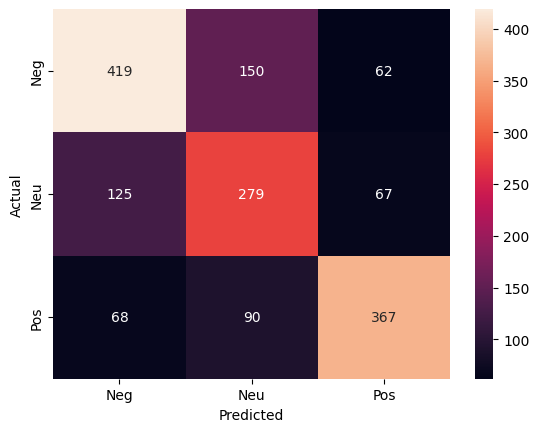

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

test_results = trainer.predict(test_ds)
predictions = test_results.predictions
if isinstance(predictions, tuple):
    predictions = predictions[0]

test_preds = np.argmax(predictions, axis=-1)
test_labels = test_results.label_ids

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Full Fine Tuning

In [ ]:
from transformers import MBartForSequenceClassification
import torch

full_model = MBartForSequenceClassification.from_pretrained(
    "facebook/mbart-large-50",
    num_labels=3,
    ignore_mismatched_sizes=True
)

full_model.gradient_checkpointing_enable()
full_model.config.use_cache = False

full_model = full_model.to("cuda")

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./mbart_full_ft",
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    num_train_epochs=2,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True,
    optim="adafactor",
    logging_steps=200,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

In [ ]:
from transformers import default_data_collator
from accelerate.state import AcceleratorState, PartialState

AcceleratorState._reset_state(reset_partial_state=True)
PartialState()

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=full_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
import torch
import time

torch.cuda.empty_cache()

start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Total Training Time: {end_time - start_time:.2f} seconds")

In [ ]:
def full_predict_sentiment(text, neutral_threshold=0.65):
  full_model.eval()
  device = next(full_model.parameters()).device

  text = clean_text(text)
  text = emoji.demojize(text)
  text = normalize_roman(text)
  text = remove_repeats(text)

  inputs = tokenizer(
      text, return_tensors="pt",
      padding=True, truncation=True, max_length=128
  ).to(device)

  with torch.no_grad():
      logits = full_model(**inputs).logits

  probs = torch.softmax(logits, dim=-1)[0]


  if probs[1] >= neutral_threshold:
      pred = 1
  else:
      neg_pos_probs = probs.clone()
      neg_pos_probs[1] = 0
      pred = torch.argmax(neg_pos_probs).item()

  label_map = {
      0: "Negative (Anger/Sad/Fear/Disgust)",
      1: "Neutral",
      2: "Positive (Happy/Surprise)"
  }
  print(f"Prediction : {label_map[pred]}")
  print(f"Confidence → Neg: {probs[0]:.3f} | Neu: {probs[1]:.3f} | Pos: {probs[2]:.3f}")
  return label_map[pred]

In [ ]:
reviews = [
    "Bro bahut acha tha. I really enjoyed it.",
    "Maza nahi aaya.",
    "Service theek thi, kuch special nahi tha.",
    "Food bahut tasty tha.",
    "Staff ka behavior acha nahi tha.",
    "Overall experience average tha.",
    "Price thoda zyada laga.",
    "Jagah clean thi aur environment acha tha.",
    "Waiting time bahut zyada tha.",
    "Theek tha, na zyada acha na bura.",
    "Quality expected se better thi.",
    "Presentation achi thi lekin taste normal tha.",
    "Bilkul pasand nahi aaya.",
    "Value for money laga.",
    "Ambience kaafi boring tha.",
    "Experience kaafi acha raha."
]

print("Full Fine Tuning Sentiment Analysis")
for review in reviews:
    print("Review:", review)
    print("Predicted Sentiment:", full_predict_sentiment(review))
    print("-" * 40)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

test_results = trainer.predict(test_ds)
predictions = test_results.predictions
if isinstance(predictions, tuple):
    predictions = predictions[0]

test_preds = np.argmax(predictions, axis=-1)
test_labels = test_results.label_ids

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()